# Methods for minimizing a bidimensional function

In [2]:
using Pkg
ENV["PYTHON"] = ""
Pkg.build("PyCall")

    Building Conda ─→ `~/.julia/scratchspaces/44cfe95a-1eb2-52ea-b672-e2afdf69b78f/8f06b0cfa4c514c7b9546756dbae91fcfbc92dc9/build.log`
    Building PyCall → `~/.julia/scratchspaces/44cfe95a-1eb2-52ea-b672-e2afdf69b78f/9816a3826b0ebf49ab4926e2b18842ad8b5c8f04/build.log`


In [14]:
function golden_section(f, a, b, eps, alpha, max_iters = 1000000)
  lambda = a + (1 - alpha) * (b - a)
  mu = a + alpha * (b - a)
  f_lambda = f(lambda)
  f_mu = f(mu)

  while abs(b - a) > eps && max_iters > 0
    if f_lambda >= f_mu
      a = lambda
      lambda = mu
      f_lambda = f_mu
      mu = a + alpha * (b - a)
      f_mu = f(mu)
    else
      b = mu
      mu = lambda
      f_mu = f_lambda
      lambda = a + (1 - alpha) * (b - a)
      f_lambda = f(lambda)
    end

    max_iters -= 1
  end

  res = (a + b) / 2.0
  return a, b, res, f(res)
end

golden_section (generic function with 2 methods)

In [ ]:
using ForwardDiff
using LinearAlgebra

function dfp(f, x0::AbstractVector, eps::Real, max_iter::Int = 1000, verbose::Bool = false)
  x = copy(x0)
  k = 1
  n = length(x)
  
  D = Matrix{Float64}(I, n, n)
  
  while k <= max_iter
    grad = ForwardDiff.gradient(f, x)
    
    if norm(grad) < eps
      return (xmin = x, fmin = f(x), iterations = k)
    end
    
    d = -D * grad
    
    phi(lam) = f(x + lam * d)
    _, _, lambda, _ = golden_section(phi, 0, 10, 1e-6, (sqrt(5) - 1) / 2)
    
    if k == 1 && verbose
      println("First iter: D =")
      display(D)
      println("lambda = $lambda")
      println("-"^20)
    end

    x = x + lambda * d
    
    grad_new = ForwardDiff.gradient(f, x)
    if norm(grad_new) < eps
      return (xmin = x, fmin = f(x), iterations = k)
    end
    
    p = lambda * d
    q = grad_new - grad
    
    term1 = (p * transpose(p)) / dot(p, q)
    term2 = (D * q * transpose(q) * D) / dot(q, D * q)
    
    D = D + term1 - term2
    
    k += 1
  end
  
  return (xmin = x, fmin = f(x), iterations = max_iter)
end

dfp (generic function with 2 methods)

### Comparison and plotting of all methods

In [4]:
using Plots
using Printf
using BenchmarkTools

function calculate_min_2d(alg, alg_name, f, x0, eps = 1e-4)
  result = alg(f, x0, eps)

  @printf("\n%s method: ", alg_name)
  @btime $alg($f, $x0, $eps)
  @printf("Minimum found at: x ~= [%.4f, %.4f]\n", result.xmin[1], result.xmin[2])
  @printf("With f(x) min ~= %.5e in %d iterations\n", result.fmin, result.iterations)

  x1_vals = range(min(x0[1], result.xmin[1]) - 1, max(x0[1], result.xmin[1]) + 1, length=100)
  x2_vals = range(min(x0[2], result.xmin[2]) - 1, max(x0[2], result.xmin[2]) + 1, length=100)
  
  f_plot(x, y) = f([x, y])
  p = contour(x1_vals, x2_vals, f_plot, levels=30, color=:viridis, xlabel="x1", ylabel="x2")

  scatter!(p, [x0[1]], [x0[2]], color=:blue, label="Start x0", markersize=4)
  scatter!(p, [result.xmin[1]], [result.xmin[2]], color=:red, label="Min found", markershape=:star5, markersize=6)

  annotate!(p, result.xmin[1], result.xmin[2], text("  Min", :left, :bottom, 8))
  
  return p
end

calculate_min_2d (generic function with 2 methods)

### Results for different functions and intervals

2×2 Matrix{Float64}:
 1.0  0.0
 0.0  1.0

2×2 Matrix{Float64}:
 1.0  0.0
 0.0  1.0

2×2 Matrix{Float64}:
 1.0  0.0
 0.0  1.0

2×2 Matrix{Float64}:
 1.0  0.0
 0.0  1.0

2×2 Matrix{Float64}:
 1.0  0.0
 0.0  1.0

...

2×2 Matrix{Float64}:
 1.0  0.0
 0.0  1.0

2×2 Matrix{Float64}:
 1.0  0.0
 0.0  1.0

2×2 Matrix{Float64}:
 1.0  0.0
 0.0  1.0

2×2 Matrix{Float64}:
 1.0  0.0
 0.0  1.0

2×2 Matrix{Float64}:
 1.0  0.0
 0.0  1.0

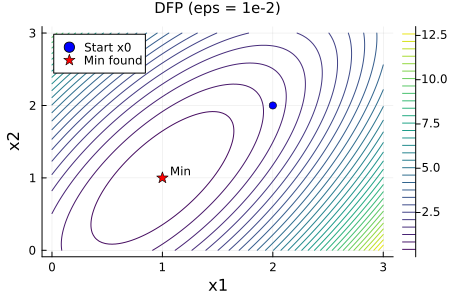

In [34]:
f_target(x) = (x[1] - 1)^2 + (x[1] - x[2])^2
x_init = [2.0, 2.0]
# f_target(x) = (x[1] - 1)^2 + 100*(x[2] - x[1]^2)^2
# x_init = [-1.2, 1.0]

test_cases = [
  (name="DFP (eps = 1e-2)", alg=dfp, f=f_target, x0=x_init, eps=1e-1),
]

all_plots = []

for tc in test_cases
  println("\n" * "-"^40)
  println("EVALUATING: $(tc.name)")
  println("-"^40)
  
  p = calculate_min_2d(tc.alg, tc.name, tc.f, tc.x0, tc.eps)
  
  title!(p, tc.name, titlefontsize=10) 
  
  push!(all_plots, p)
end

n_cols = 1
n_rows = ceil(Int, length(test_cases) / n_cols)

plot(all_plots..., layout=(n_rows, n_cols), size=(450 * n_cols, 300 * n_rows))